# Looqbox Data Challenge

Candidato: Cássio Lima  
Data:  26/06/2026  

# Comentarios sobre o teste e clarificacao de utilizacao de inteligencia artificial

De modo geral no teste, nao utilizei de ferramentas de inteligencia artificial para desenvolvimento integral dos blocos de codigo. No entando, potentualmente, devido a feature de "autocompletar' do Visual Studio Code, algumas vezes utilizei-me da mesma para agilizar descricao de campos e syntax de campo. 

Ponto que fiz o uso de inteligencia artificial (Large Language Model):

Durante o Desafio 3, ao plotar a tabela "Movies", passei a variavel labels e observei o seguinte erro: 

```bash
TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?
```

Ao buscar solucoes na internet, perguntei ao DeepSeek-v4-flash qual seria o problema com meu codigo (entendo que poderia ter aberto a lista de variaveis aceitaveis tambem) e obtive como resposta:

"matplotlib atualizou — labels= virou tick_labels= da versao 3.9+."

Entao, troquei labels por tick_labels.

## 1. Setup conexoes e rodando uns testes basicos de conexao

In [15]:
import mysql.connector # Importando a biblioteca mysql.connector para conectar ao banco de dados MySQL
import pandas as pd # Importando a biblioteca pandas para manipulação de dados, pandas eh minha preferencia
import matplotlib.pyplot as plt # Classico matplotlib
import seaborn as sns # Seaborn por estilo e praticidade
from typing import Optional, List, Union # 

DB_CONFIG = {
    'host': '35.199.115.174',
    'user': 'looqbox-challenge',
    'password': 'looq-challenge',
    'database': 'looqbox-challenge'
}

connection = mysql.connector.connect(**DB_CONFIG)
print('Conectado.')
print(f'Tabelas disponiveis:')
cursor = connection.cursor() # Cursor aqui tem a funcao de executar comandos SQL e retornar resultados
cursor.execute('SHOW TABLES') # Vamos executar o comando SQL SHOW TABLES para listar todas as tabelas no banco de dados
for t in cursor.fetchall(): # Interando sobre os resultados retornados pelo comando SQL, para ver todas tabelas
    print(f'  - {t[0]}')
cursor.close() # Fechar a conexao com o cursor, para liberar recursos

Conectado.
Tabelas disponiveis:
  - IMDB_movies
  - data_product
  - data_product_sales
  - data_store_cad
  - data_store_sales


True

In [16]:
# Inspecao basica da primeira tabela que apareceu no print IMDB_movies

cursor = connection.cursor() # Cursor aqui tem a funcao de executar comandos SQL e retornar resultados
cursor.execute('DESCRIBE IMDB_movies')
for col in cursor.fetchall():
        print(col)
cursor.close()


('Id', 'int', 'NO', 'PRI', None, '')
('Title', 'varchar(255)', 'YES', '', None, '')
('Genre', 'varchar(255)', 'YES', '', None, '')
('Director', 'varchar(255)', 'YES', '', None, '')
('Actors', 'varchar(255)', 'YES', '', None, '')
('Year', 'int', 'YES', '', None, '')
('Runtime', 'int', 'YES', '', None, '')
('Rating', 'decimal(10,0)', 'YES', '', None, '')
('Votes', 'int', 'YES', '', None, '')
('RevenueMillions', 'decimal(10,0)', 'YES', '', None, '')
('Metascore', 'int', 'YES', '', None, '')


True

## SQL Test

Agora performamos as operacoes pro teste.

### Q1 — Top 10 produtos mais caros

In [17]:
# Vamos ver como a tabela data_product se parece, para isso vamos usar o pandas para ler os dados e mostrar as primeiras linhas
cursor = connection.cursor() # Cursor aqui tem a funcao de executar comandos SQL e retornar resultados
cursor.execute('DESCRIBE data_product')
for col in cursor.fetchall():
        print(col)
cursor.close()

('PRODUCT_COD', 'int', 'NO', 'PRI', None, '')
('PRODUCT_NAME', 'varchar(150)', 'YES', 'MUL', None, '')
('PRODUCT_VAL', 'decimal(8,2)', 'YES', '', None, '')
('DEP_NAME', 'varchar(255)', 'YES', '', None, '')
('DEP_COD', 'int', 'YES', '', None, '')
('SECTION_NAME', 'varchar(255)', 'YES', '', None, '')
('SECTION_COD', 'int', 'YES', '', None, '')


True

In [18]:
# Ja que varios calls para o banco de dados serao feitos, vamos criar uma funcao para agializar. 
# Dai so passamos o SQL e a funcao retorna um DataFrame do pandas com os resultados

def query(sql): 
        cursor = connection.cursor(dictionary=True)
        cursor.execute(sql)
        df = pd.DataFrame(cursor.fetchall())
        cursor.close()
        return df

In [19]:
# Trazer a tabela para pandas, minha preferencia, para poder manipular os dados e fazer analises
# O query abaixo traz os 10 produtos mais caros, com seus respectivos codigos, nomes, valores, 
# departamentos e secoess. A ordenacao eh feita pelo valor do produto em ordem decrescente.

q1 = """
SELECT product_cod, product_name, product_val, dep_name, section_name
FROM data_product
ORDER BY product_val DESC
LIMIT 10
"""
df_q1 = query(q1)
df_q1


,product_cod,product_name,product_val,dep_name,section_name
0,301409,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...,741.99,BEBIDAS,BEBIDAS
1,176185,Whisky Escoces JOHNNIE WALKER Blue Label Garra...,735.90,BEBIDAS,BEBIDAS
2,315481,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00,BEBIDAS,BEBIDAS
3,100280,Vinho Portugues Tinto Vintage QUINTA DO CRASTO...,445.90,BEBIDAS,VINHOS
4,320046,Escova Dental Eletrica ORAL B D34 Professional...,399.90,PERFUMARIA,HIGIENE BUCAL
5,190817,Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...,366.90,MERCEARIA,ARTIGOS-PARA-O-LAR
6,153795,Champagne Frances Brut Imperial MOET Rose Garr...,359.90,MERCEARIA,ARTIGOS-PARA-O-LAR
7,311397,Conjunto de Panelas Allegra em Inox TRAMONTINA...,359.00,MERCEARIA,ARTIGOS-PARA-O-LAR
8,147706,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90,BEBIDAS,BEBIDAS
9,154431,Champagne Frances Brut Imperial MOET & CHANDON...,315.90,MERCEARIA,ARTIGOS-PARA-O-LAR


### Q2 — Seções dos departamentos BEBIDAS e PADARIA

In [20]:
# Abaixo restringimos nossa consulta para trazer apenas os departamentos de BEBIDAS e PADARIA,
#  com suas respectivas secoess. A ordenacao eh feita pelo nome do departamento e da secao.

q2 = """
SELECT DISTINCT dep_name, section_name
FROM data_product
WHERE dep_name IN ('BEBIDAS', 'PADARIA')
ORDER BY dep_name, section_name
"""

df_q2 = query(q2)
df_q2

,dep_name,section_name
0,BEBIDAS,BEBIDAS
1,BEBIDAS,CERVEJAS
2,BEBIDAS,REFRESCOS
3,BEBIDAS,VINHOS
4,PADARIA,DOCES-E-SOBREMESAS
5,PADARIA,GESTANTE
6,PADARIA,PADARIA
7,PADARIA,QUEIJOS-E-FRIOS


### Q3 — Total vendido por Business Area no Q1 2019

In [21]:
# Abaixo selecionamos por business area (nome aqui BUSINESS_NAME) e somamos o valor de vendas (SALES_VALUE) para cada business area, 
# no periodo de 01/01/2019 a 31/03/2019. A ordenacao eh feita pelo total de vendas em ordem decrescente.

q3 = """
SELECT c.BUSINESS_NAME,
       ROUND(SUM(v.SALES_VALUE), 2) AS total_sales
FROM data_store_sales v
JOIN data_store_cad c USING (STORE_CODE)
WHERE v.DATE BETWEEN '2019-01-01' AND '2019-03-31'
GROUP BY c.BUSINESS_NAME
ORDER BY total_sales DESC
"""

df_q3 = query(q3)
df_q3

,BUSINESS_NAME,total_sales
0,Farma,81776691.73
1,Varejo,81032347.65
2,Atacado,80384884.60
3,Proximidade,80171122.80
4,Posto,32072326.40



## Case Real 1 - Função dinâmica "retrieve_data"

Objetivo: Criar uma função flexível que monta queries dinamicamente com base em 3 parâmetros (Assumindo aqui que sejam opcionais)

In [22]:
# Aqui definimos a funcao retrieve_data que recebe como parametros o codigo do produto, 
# codigo da loja, data e conexao com o banco de dados.
# A funcao tem como campos opcionais o codigo do produto, codigo da loja e data, que podem ser passados como argumentos.
   
def retrieve_data(      
        product_code: Optional[int] = None,
        store_code: Optional[int] = None,
        date: Optional[List[str]] = None,
        conn=None # conn aqui tem a funcao de receber uma conexao com o banco de dados, caso nao seja passada, a funcao cria uma nova conexao
    ) -> pd.DataFrame: # A funcao retorna um DataFrame do pandas com os resultados da consulta SQL.
        cfg = conn or mysql.connector.connect(**DB_CONFIG) # Conecta ao banco de dados
        close = conn is None  # so fecha se criou aqui
    
        clauses, params = [], [] # definindo listas vazias para armazenar as clausulas e parametros da consulta SQL
        # Logica aqui eh simples, se o parametro for passado, adiciona a clausula e o parametro na lista, caso 
        # contrario nao faz nada.
        # A adicao de %s eh uma seguranca para evitar SQL injection, o parametro sera passado separadamente e 
        # nao sera concatenado na string SQL.
        if product_code is not None: 
            clauses.append("AND PRODUCT_CODE = %s"); params.append(product_code) 
        if store_code is not None:
            clauses.append("AND STORE_CODE = %s"); params.append(store_code)
        if date and len(date) == 2:
            clauses.append("AND DATE BETWEEN %s AND %s"); params.extend(date)
    
        # uma vez que todas as clausulas foram adicionadas, podemos montar a query final e executar
        # A funcao pd.read_sql() do pandas eh usada para executar a query e retornar um DataFrame com os resultados.

        query = "SELECT * FROM data_product_sales WHERE 1=1 " + " ".join(clauses)  # Aqui temos certeza que trazemos todas colunas
        df = pd.read_sql(query, cfg, params=params)
        if close: cfg.close()
        return df

# OBS: Caso a funcao seja usada por outros times, como sugerido pelo desafio, a funcao pode ser melhorada para receber outros parametros, como por exemplo,
# o nome do produto, o nome da loja, o departamento, a secao. Eh possivel tambem que a funcao seja convertida a um modulo, para que outros times possam 
# importar e usar a funcao sem precisar copiar o codigo.

#### Testes da função

In [23]:
# Primeiro vamos dar uma olhada na tabela para retirar um produto que existe numa loja

q4 = """
SELECT store_code, product_code, date, sales_value, sales_qty
FROM data_product_sales
LIMIT 10
"""
df_q4 = query(q4)
df_q4

,store_code,product_code,date,sales_value,sales_qty
0,1,18,2019-01-01,708.50,65
1,1,18,2019-01-02,1297.10,119
2,1,18,2019-01-03,1144.50,105
3,1,18,2019-01-04,1090.00,100
4,1,18,2019-01-05,893.80,82
5,1,18,2019-01-06,741.20,68
6,1,18,2019-01-07,654.00,60
7,1,18,2019-01-08,741.20,68
8,1,18,2019-01-09,1373.40,126
9,1,18,2019-01-10,1068.20,98


In [24]:
# Testando o produce 18 pq ele existe (de acordo com o report acima) para validacao no mes de janeiro de 2019

df_multi = retrieve_data(product_code=18, store_code=1, date=['2019-01-01', '2019-01-31'])
print(f'Produtos 18: {len(df_multi)} rows')
df_multi

/var/folders/gx/xtw1gyms3cd4csdtf8k5bzc80000gn/T/ipykernel_46254/3076841265.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cfg, params=params)


Produtos 18: 31 rows


,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,18,2019-01-01,708.5,65.0
1,1,18,2019-01-02,1297.1,119.0
2,1,18,2019-01-03,1144.5,105.0
3,1,18,2019-01-04,1090.0,100.0
4,1,18,2019-01-05,893.8,82.0
5,1,18,2019-01-06,741.2,68.0
6,1,18,2019-01-07,654.0,60.0
7,1,18,2019-01-08,741.2,68.0
8,1,18,2019-01-09,1373.4,126.0
9,1,18,2019-01-10,1068.2,98.0



## Case 2 — Queries fixas + visualização

Instruções do cliente:
- Nao eh permitido modificar as queries
- Filtrar período inteiro de 2019 (2019-01-01 a 2019-12-31)
- Criar visualização: ranking de lojas por TM (ticket médio?)

In [25]:
# Query 1

query1 = """SELECT
      STORE_CODE,
      STORE_NAME,
      START_DATE,
      END_DATE,
      BUSINESS_NAME,
      BUSINESS_CODE
FROM data_store_cad"""

# Query 2
query2 = """SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'"""

df_cad = query(query1)
df_sales = query(query2)

# vamos verificar oq esta retornando e se esta ok, para isso vamos printar o tamanho dos dataframes retornados
print(f'Cadastro: {len(df_cad)} lojas')
print(f'Vendas 2019: {len(df_sales)} registros')

Cadastro: 20 lojas
Vendas 2019: 7300 registros


In [26]:
# Filtro manual do periodo (sem mexer nas queries)
df_sales['DATE'] = pd.to_datetime(df_sales['DATE']) # Por nao ter certeza que o campo DATE esta no formato datetime, vamos converter para datetime, caso nao esteja.
mask = (df_sales['DATE'] >= '2019-10-01') & (df_sales['DATE'] <= '2019-12-31') # Mask simples de data para so pegar Q4
df_q4 = df_sales[mask].copy() # criar um novo dataframe com os dados filtrados, para nao alterar o dataframe original

# Verificar se o dataframe se mantem agora pegando apenas uma fatia de 2019
print(f'Q4 2019: {len(df_q4)} registros')
df_q4

Q4 2019: 1840 registros


,STORE_CODE,DATE,SALES_VALUE,SALES_QTY
5460,1,2019-10-01,187601.54,12160
5461,10,2019-10-01,139038.86,5223
5462,11,2019-10-01,252687.35,8481
5463,12,2019-10-01,223973.64,7659
5464,13,2019-10-01,187601.54,12160
...,...,...,...,...
7295,5,2019-12-31,193619.94,12607
7296,6,2019-12-31,193619.94,12607
7297,7,2019-12-31,193619.94,12607
7298,8,2019-12-31,191704.64,12500


In [27]:
# Calcula TM = total vendido / total qtd
# Para isso vamos agrupar por STORE_CODE e somar o SALES_VALUE e SALES_QTY, 
# depois vamos calcular o TM dividindo o total de vendas pelo total de quantidade vendida.

df_agg = df_q4.groupby('STORE_CODE').agg(
    total_value=('SALES_VALUE', 'sum'),
    total_qty=('SALES_QTY', 'sum')
).reset_index()

# Agora criando essa columna TM, como esperado e usando round para arredondar para 2 casas 
# decimais, como sugerido pelo desafio.
df_agg['TM'] = (df_agg['total_value'] / df_agg['total_qty']).round(2)

# Junta com dados da loja, para obter o mesmo resultado devemos 
# dar sort por ordem alfabetica do nome da loja

df_rank = df_agg.merge(
    df_cad[['STORE_CODE', 'STORE_NAME', 'BUSINESS_NAME']],
    on='STORE_CODE'
).sort_values('STORE_NAME').reset_index(drop=True)

df_rank

,STORE_CODE,total_value,total_qty,TM,STORE_NAME,BUSINESS_NAME
0,14,21213088.57,1378476,15.39,Bahia,Atacado
1,18,8376271.00,612968,13.67,Bangkok,Posto
2,8,20989553.37,1365988,15.37,Belem,Proximidade
3,6,21213088.57,1378476,15.39,Berlin,Proximidade
4,15,21213088.57,1378476,15.39,Buenos Aires,Atacado
5,2,21928421.28,1412372,15.53,Chicago,Varejo
6,13,21213088.57,1378476,15.39,Dubai,Atacado
7,10,15039911.54,570745,26.35,Hong Kong,Farma
8,9,19471788.15,671638,28.99,London,Farma
9,12,24129399.10,831168,29.03,Madri,Farma


<Axes: xlabel='TM', ylabel='Loja'>

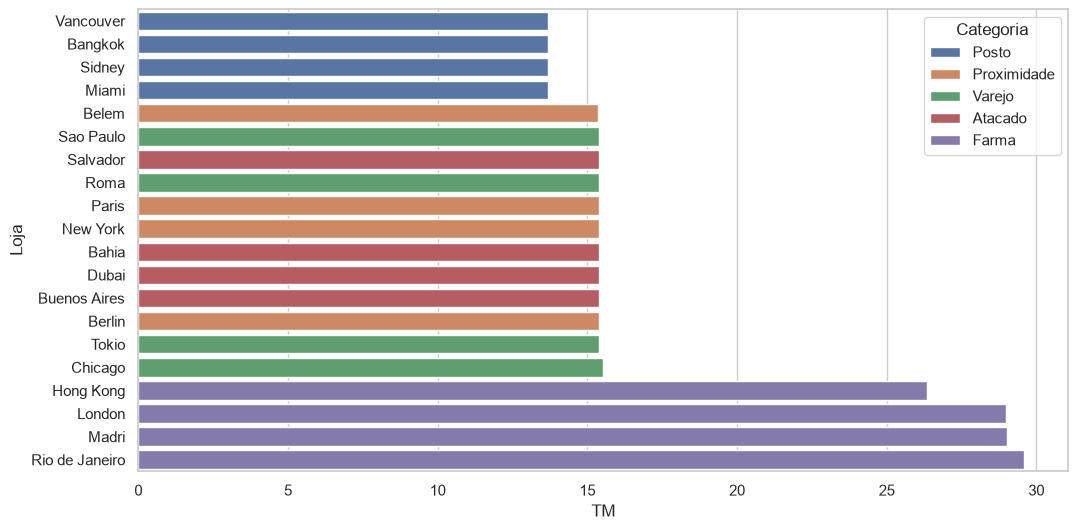

In [28]:
# Proximo passar visualizar o plot acima, considerando apenas as colunas STORE_NAME, TM e BUSINESS_NAME
#  para isso vamos usar o seaborn para plotar um grafico de barras, com o eixo x sendo o nome da loja e o eixo y 

import seaborn as sns
import matplotlib.pyplot as plt


# Inicializando o estilo do seaborn para melhor visualizacao
sns.set(style="whitegrid")
f, ax = plt.subplots(figsize=(12, 6))

# Renome as colunas para facilitar o plot e bater com o desafio, que pede para mostrar Loja, Categoria e TM
df_rank = df_rank.rename(columns={'STORE_NAME': 'Loja', 'BUSINESS_NAME': 'Categoria'})

# Plottando 
sns.barplot(
    data=df_rank.sort_values('TM'),  # ordena crescente pro horizontal ficar maior em cima
    x='TM',
    y='Loja',
    hue='Categoria',
    dodge=False  # barras lado a lado, nao empilhadas
)



# Case 3 - Visualização com IMDB_movies

In [29]:
# Primeiro vamos pegar toda tabela e entender que colunas temos disponiveis 
df_movies = query('SELECT * FROM IMDB_movies')
print(f'Shape: {df_movies.shape}')
df_movies

Shape: (1000, 11)


,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8,757074,333,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7,485820,126,65.0
2,3,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7,157606,138,62.0
3,4,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7,60545,270,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6,393727,325,40.0
...,...,...,...,...,...,...,...,...,...,...,...
995,996,Secret in Their Eyes,"Crime,Drama,Mystery",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6,27585,None,45.0
996,997,Hostel: Part II,Horror,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,6,73152,18,46.0
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6,70699,58,50.0
998,999,Search Party,"Adventure,Comedy",Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,6,4881,None,22.0


In [30]:
# Como a coluna Genre tem varios generos, separador por virgula, vamos so consider o primeiro.

df_movies['main_genre'] = df_movies['Genre'].str.split(',').str[0].str.strip()

# Pra melhor visualizacao, vamos Normalizar metascore pra mesma escala (0-10) pra comparacao direta
df_plot = df_movies.dropna(subset=['Rating', 'Metascore']).copy() # Nao parece ter Na, mas pra evitar problemas
df_plot['Rating'] = pd.to_numeric(df_plot['Rating']) # Garantir que os campos sao numericos
df_plot['Metascore'] = pd.to_numeric(df_plot['Metascore'])
df_plot['MetaNorm'] = df_plot['Metascore'] / 10 # Normal

# Calcula diferenca publico vs critica e adiciona como coluna
df_plot['Diff'] = df_plot['Rating'] - df_plot['MetaNorm']

# Top 6 generos pra nao poluir (Outras visualizacoes ficaram muito densas)
top6 = df_plot['main_genre'].value_counts().head(6).index
print(f'Top 6 generos: {top6.tolist()}') # Printando pq vamos hardcodar as cores no proximo

df_plot = df_plot[df_plot['main_genre'].isin(top6)]
df_plot


Top 6 generos: ['Action', 'Drama', 'Comedy', 'Adventure', 'Crime', 'Biography']


,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore,main_genre,MetaNorm,Diff
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333,76.0,Action,7.6,0.4
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126,65.0,Adventure,6.5,0.5
4,5,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.0,393727,325,40.0,Action,4.0,2.0
5,6,The Great Wall,"Action,Adventure,Fantasy",Yimou Zhang,"Matt Damon, Tian Jing, Willem Dafoe, Andy Lau",2016,103,6.0,56036,45,42.0,Action,4.2,1.8
6,7,La La Land,"Comedy,Drama,Music",Damien Chazelle,"Ryan Gosling, Emma Stone, Rosemarie DeWitt, J....",2016,128,8.0,258682,151,93.0,Comedy,9.3,-1.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,995,Project X,Comedy,Nima Nourizadeh,"Thomas Mann, Oliver Cooper, Jonathan Daniel Br...",2012,88,7.0,164088,55,48.0,Comedy,4.8,2.2
995,996,Secret in Their Eyes,"Crime,Drama,Mystery",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.0,27585,None,45.0,Crime,4.5,1.5
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.0,70699,58,50.0,Drama,5.0,1.0
998,999,Search Party,"Adventure,Comedy",Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,6.0,4881,None,22.0,Adventure,2.2,3.8


# Explicacao de visualizacao

1. Data o shape do dataframe acima, acredito que seria interessante dois graficos que ilustrem a relacao Rating x Metacritica, para saber se existe uma correlacao entre a nota dada entre o publico e a nota dada pelos criticos de cinema ao filme. Entao um scatter plot com ambas notas em X e Y axis ficaria interessante, tracando uma linha de tentencia e

2. Se em geral o publico da uma nota acima ou abaixo media para os generos que os criticos. Para isso, boxplot com umas estatistcas de variacao podem ser bem informativas sobre a dispersao dos dados.

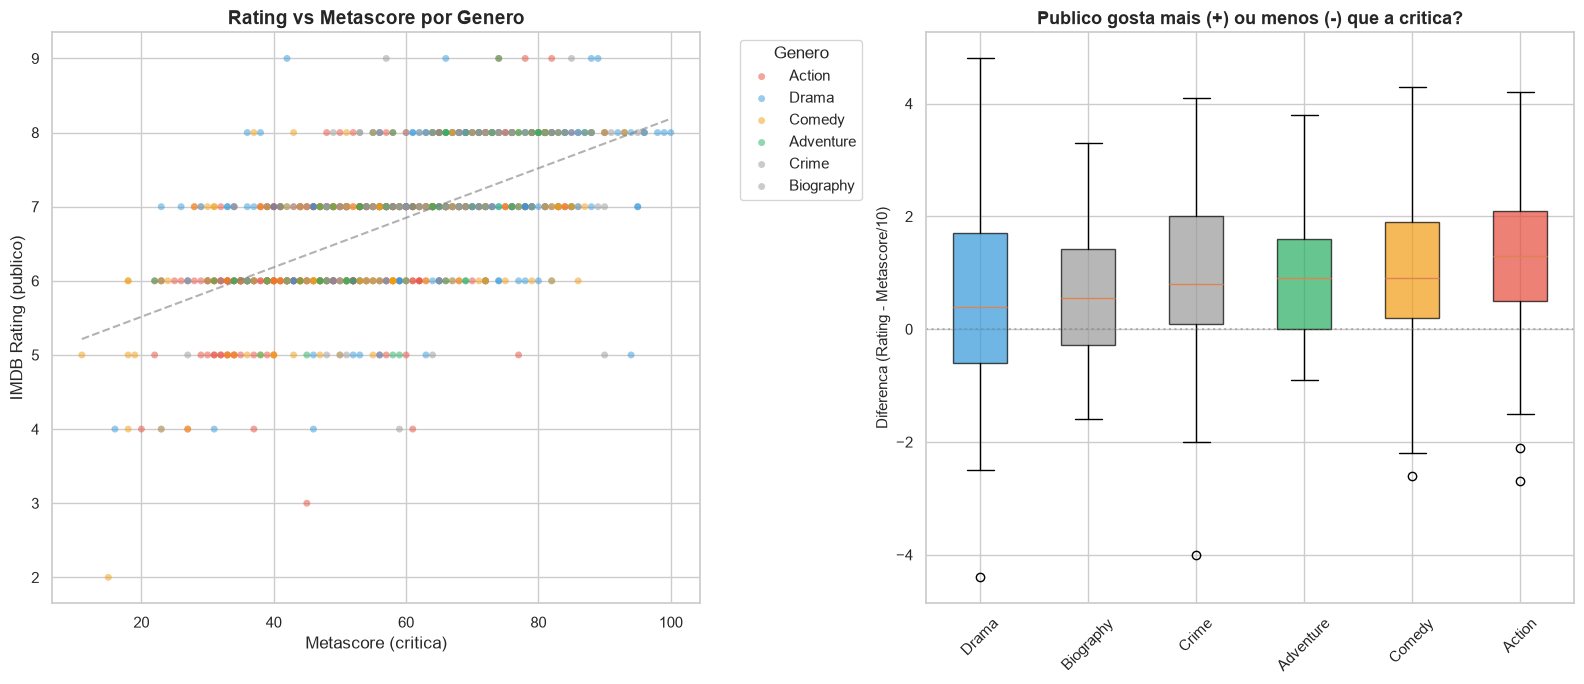

In [31]:
import numpy as np # aqui numpy realmente ajuda a calcular a linha de tendencia

# Comecando o grafico com subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = {'Action':'#E74C3C','Comedy':'#F39C12','Drama':'#3498DB',
          'Horror':'#2C3E50','Thriller':'#9B59B6','Adventure':'#27AE60'}

ax = axes[0]
for genre in top6:
    sub = df_plot[df_plot['main_genre'] == genre].dropna(subset=['Metascore', 'Rating'])
    ax.scatter(sub['Metascore'], sub['Rating'], c=colors.get(genre,'#999'),
               label=genre, alpha=0.5, s=25, edgecolors='none')

# Linha de tendencia
clean = df_plot[['Metascore', 'Rating']].dropna()
z = np.polyfit(clean['Metascore'], clean['Rating'], 1)
p = np.poly1d(z)
ax.plot(sorted(clean['Metascore']), p(sorted(clean['Metascore'])),
        color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
ax.set_xlabel('Metascore (critica)', fontsize=12)
ax.set_ylabel('IMDB Rating (publico)', fontsize=12)
ax.set_title('Rating vs Metascore por Genero', fontsize=14, fontweight='bold')
ax.legend(title='Genero', bbox_to_anchor=(1.05, 1), loc='upper left')

ax2 = axes[1]
order = df_plot.groupby('main_genre')['Diff'].median().sort_values().index
bp = ax2.boxplot([df_plot[df_plot['main_genre']==g]['Diff'].dropna() for g in order],
                 tick_labels=order, patch_artist=True, widths=0.5)
for patch, genre in zip(bp['boxes'], order):
    patch.set_facecolor(colors.get(genre, '#999'))
    patch.set_alpha(0.7)
ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax2.set_ylabel('Diferenca (Rating - Metascore/10)', fontsize=11)
ax2.set_title('Publico gosta mais (+) ou menos (-) que a critica?', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()